# Customer Churn Prediction

End-to-end scikit-learn pipeline: **EDA → preprocessing → modeling → tuning → evaluation → interpretability**.

## Why this project exists

Telecom churn is expensive: acquiring a new customer usually costs more than retaining an existing one. The goal is not only to predict *who* will churn, but to:

1. **Rank customers by churn risk** (so retention teams can prioritize outreach)
2. **Catch as many true churners as possible** (high recall on the churn class — missed churners are costly)
3. **Explain the main drivers** (so product/marketing can act on contract, tenure, services, etc.)

## How to read this notebook

Each section explains **what** we do and **why** that decision was made. Metrics and plots are the evidence behind later modeling choices.


## 0. Setup

We fix a `RANDOM_STATE` for reproducibility and define `FIGURES_DIR` so every plot is saved under `graphs/` (works whether the kernel cwd is the repo root or `notebooks/`).


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

FIGURES_DIR = Path("graphs") if Path("graphs").is_dir() else Path("../graphs")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Figures will be saved to:", FIGURES_DIR.resolve())

Figures will be saved to: /Users/shrutidoshi/Documents/repo/customer-churn-prediction-sklearn/graphs


## 1. Load data

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — ~7k customers with demographics, services, billing, and a binary churn label.

**Why this dataset?** It is a standard churn benchmark with mixed numeric + categorical features and realistic class imbalance (~27% churn), which forces the same design choices you'd make in production (pipelines, stratified splits, imbalance handling).

**Path note:** Prefer opening this notebook with the project root as the working directory (`jupyter.notebookFileRoot` = `${workspaceFolder}` in Cursor/VS Code) so `data/...` resolves cleanly.


In [49]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Inspect dtypes and missing values

Before modeling we check:

- **dtypes** — `TotalCharges` often arrives as a string (blank values), so it cannot be treated as numeric yet
- **nulls** — tells us whether we need imputation, and whether "missingness" itself might be informative


In [50]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [51]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 2. Clean data

Decisions in this section are intentional:

| Decision | Why |
|---|---|
| `pd.to_numeric(..., errors='coerce')` on `TotalCharges` | Blank/invalid strings become NaN instead of crashing later transforms |
| Fill NaNs with the **median** | Robust to outliers vs mean; few missing rows, so simple imputation is enough |
| Drop `customerID` | Identifier only — including it would leak a meaningless unique key into the model |

We clean **before** the train/test split here because these steps are deterministic row-local transforms (no statistics learned from the full target). Scaling / encoding happen later **inside** a pipeline fit on training data only.


In [52]:
# Coerce TotalCharges; blanks become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges NaNs after coerce:", df["TotalCharges"].isnull().sum())

# Median imputation for the few invalid TotalCharges rows
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Drop ID column — not a predictive feature
df = df.drop("customerID", axis=1)

print("Remaining nulls:", df.isnull().sum().sum())
df.shape

TotalCharges NaNs after coerce: 11
Remaining nulls: 0


(7043, 20)

## 3. Exploratory data analysis (EDA)

EDA answers two modeling questions early:

1. **How imbalanced is churn?** → drives metric choice (`roc_auc` over accuracy) and `class_weight='balanced'`
2. **Do obvious billing features separate churners?** → validates that tenure / charges are worth keeping as numeric inputs


### 3.1 Class balance

If churn is rare, a model can get high accuracy by always predicting "No Churn" while being useless for retention. We therefore track **ROC-AUC** (ranking quality) and **churn recall** (fraction of true churners we catch).


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


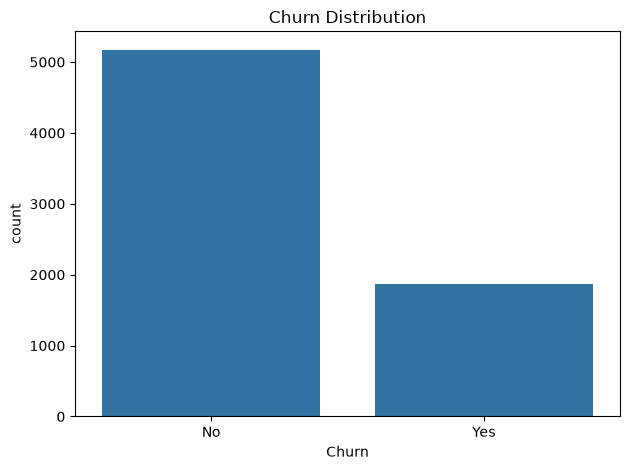

In [65]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**EDA conclusion — imbalance:** Churn is the minority class (~26–27%). Accuracy alone is the wrong North Star; we will optimize ranking metrics and pay special attention to recall on class `1` (churn).


### 3.2 Tenure and monthly charges vs churn

Business intuition: new customers (low tenure) and high-bill customers may churn more. Boxplots check whether the data supports that before we invest in complex models.


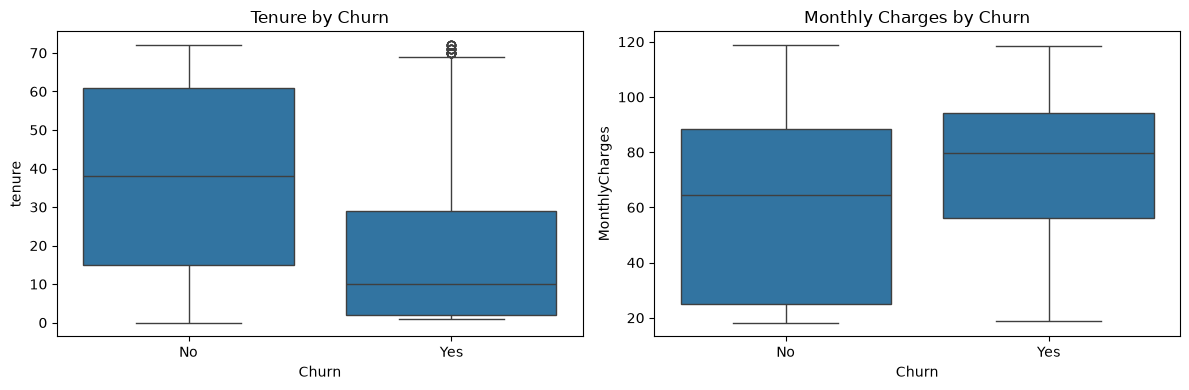

Median tenure by churn:
 Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64
Median MonthlyCharges by churn:
 Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="Churn", y="tenure", data=df, ax=axes[0])
axes[0].set_title("Tenure by Churn")
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=axes[1])
axes[1].set_title("Monthly Charges by Churn")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tenure_monthlycharges_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

print("Median tenure by churn:\n", df.groupby("Churn")["tenure"].median())
print("Median MonthlyCharges by churn:\n", df.groupby("Churn")["MonthlyCharges"].median())

**EDA conclusion — features:** Churners tend to have **much shorter tenure** and **higher monthly charges**. That motivates keeping these as scaled numeric features and later checking whether contract / internet service dominate importance as well.


## 4. Train / test split

| Decision | Why |
|---|---|
| Map `Yes`/`No` → `1`/`0` | scikit-learn classifiers expect numeric labels |
| `test_size=0.2` | Hold out enough data for a stable final estimate without starving training |
| `stratify=y` | Preserve the ~27% churn rate in both splits (critical under imbalance) |
| `random_state=42` | Reproducible comparison across runs and models |
| Split **before** fitting scalers/encoders | Prevents test information from leaking into preprocessing |

The test set is a **final exam**: we use it for model comparison snapshots and final evaluation, but hyperparameter selection should rely on cross-validation on the training set.


In [67]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), "| Test churn rate:", y_test.mean().round(3))

Train: (5634, 19) Test: (1409, 19)
Train churn rate: 0.265 | Test churn rate: 0.265


## 5. Preprocessing pipeline

We use a `ColumnTransformer` so numeric and categorical columns are handled differently in one step:

| Transform | Applied to | Why |
|---|---|---|
| `StandardScaler` | `tenure`, `MonthlyCharges`, `TotalCharges` | Puts numeric features on a comparable scale (important for Logistic Regression; harmless for trees) |
| `OneHotEncoder(handle_unknown='ignore')` | all other columns | Converts categoricals to binary columns; `ignore` avoids failures if a rare category appears only in test |
| Wrapped later in a `Pipeline` | full model | Guarantees preprocessing is fit on training folds only during CV / GridSearch |

**Why not manually `fit_transform` the whole dataset first?** That would leak test (or CV-holdout) statistics into training and inflate scores.


In [68]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

print("Numeric:", len(numeric_features))
print("Categorical count:", len(categorical_features))

Numeric: 3
Categorical count: 16


## 6. Baseline — Logistic Regression

**Why start with Logistic Regression?**

- Fast, strong linear baseline for tabular binary classification
- Coefficients are easy to reason about once features are scaled / encoded
- If a complex model cannot beat it, complexity is not justified

**Why `class_weight='balanced'`?**  
It up-weights the minority (churn) class so the optimizer does not ignore churners under the ~27% base rate.

**Why report ROC-AUC + classification report?**  
ROC-AUC measures ranking quality independent of a single threshold; the report shows precision/recall at the default 0.5 threshold — especially **recall for class 1**.


In [57]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    )),
])

log_reg_pipeline.fit(X_train, y_train)
y_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = log_reg_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8414063912785139


**Baseline takeaway:** Logistic Regression already achieves strong ROC-AUC (≈0.84 in our runs) with solid churn recall. Tree ensembles must beat this bar to be worth deploying.


## 7. Compare stronger models

We try two nonlinear models that often improve on tabular data:

| Model | Why include it |
|---|---|
| **Random Forest** | Robust bagging ensemble; supports `class_weight='balanced'`; good candidate for tuning |
| **HistGradientBoosting** | Strong boosting baseline on medium-sized tabular data; handles nonlinear interactions |

We compare **test ROC-AUC** as a quick screen. This is exploratory — final model choice for tuning will also look at cross-validation on the training set (next section) to avoid over-trusting one test snapshot.


In [69]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced", random_state=RANDOM_STATE
    )),
])

hgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

for name, pipe in [("Random Forest", rf_pipeline), ("HistGradientBoosting", hgb_pipeline)]:
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    print(f"{name} ROC-AUC: {roc_auc_score(y_test, proba):.3f}")

Random Forest ROC-AUC: 0.820
HistGradientBoosting ROC-AUC: 0.835


**Comparison takeaway:** Untuned Random Forest often underperforms the logistic baseline; HistGradientBoosting is competitive. We still tune Random Forest next because depth/regularization usually fixes RF under default settings, and RF remains easy to productionize with class weights.


## 8. Cross-validation (Random Forest)

**Why CV instead of only the test set?**  
Repeatedly evaluating on the same test split encourages accidental overfitting to that split when selecting models/hyperparameters.

**Why `StratifiedKFold`?**  
Each fold keeps the churn rate similar to the full training set.

**Why score `roc_auc`?**  
Aligns with our ranking objective under class imbalance.

We CV the Random Forest pipeline on **training data only**.


In [70]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC: {scores.mean():.3f} +/- {scores.std():.3f}")
print("Fold scores:", np.round(scores, 3))

CV ROC-AUC: 0.822 +/- 0.012
Fold scores: [0.818 0.806 0.825 0.818 0.844]


## 9. Hyperparameter tuning (`GridSearchCV`)

**Why tune Random Forest?** Defaults (`max_depth=None`) can overfit; a shallower forest often generalizes better on this dataset.

**Search space rationale:**

| Hyperparameter | Values tried | Intent |
|---|---|---|
| `n_estimators` | 100, 200, 300 | More trees → more stable estimates (diminishing returns) |
| `max_depth` | 5, 10, None | Cap complexity; shallow trees often win here |
| `min_samples_split` | 2, 5, 10 | Require more samples to split → less overfitting |

**Why `GridSearchCV` on the full `Pipeline`?**  
So every fold re-fits the preprocessor on that fold's training rows only — no leakage.

**Why optimize `roc_auc`?** Same ranking objective as evaluation.


In [60]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    rf_pipeline, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Best params: {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV ROC-AUC: 0.8451866696221906


**Tuning takeaway:** The search typically selects a **shallow** forest (e.g. `max_depth=5`). That matches the earlier observation that unconstrained RF was weaker than Logistic Regression — regularization via depth was the missing piece.


## 10. Final evaluation on the held-out test set

Only now do we treat the test set as a one-shot estimate of real-world performance for the **tuned** pipeline.

Focus on:

- **Churn recall** — Did we catch most customers who will leave?
- **Churn precision** — Of predicted churners, how many are real? (drives outreach cost)
- **Confusion matrix** — Explicit FN (missed churners) vs FP (unnecessary outreach)
- **Precision–recall curve** — Shows the tradeoff if we change the decision threshold away from 0.5


              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Test ROC-AUC: 0.839030974708724


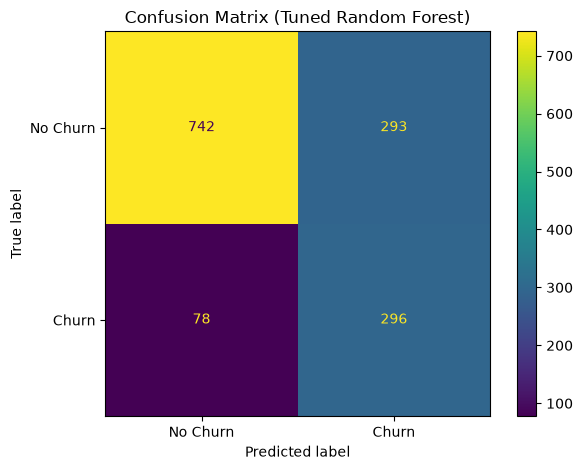

In [61]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot()
plt.title("Confusion Matrix (Tuned Random Forest)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**How to read the confusion matrix (business lens):**

- **False negatives (actual churn, predicted stay)** — the expensive mistakes we most want to minimize
- **False positives (actual stay, predicted churn)** — wasted retention offers; often acceptable if budget allows

`class_weight='balanced'` biases the model toward higher churn recall at the cost of precision. That is a deliberate product choice for retention use cases.


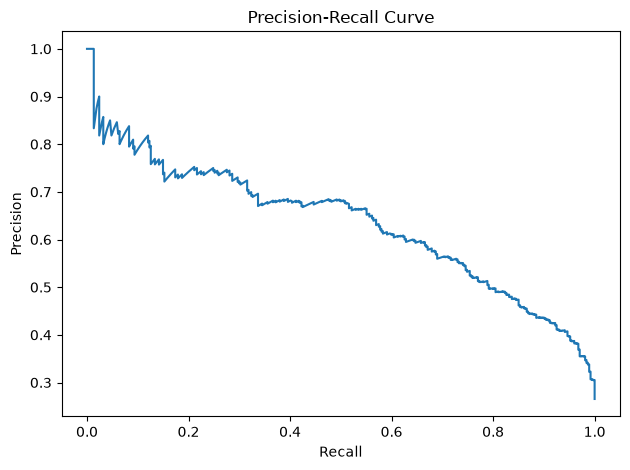

In [62]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

**PR-curve takeaway:** The default 0.5 threshold is only one operating point. If outreach capacity is limited, move up the curve (higher precision, lower recall). If missing churners is unacceptable, move toward higher recall.


## 11. Feature importance (interpretability)

**Why permutation importance (not impurity / Gini importance)?**

- Works on the **full pipeline** (preprocessor + model) without unpacking one-hot columns by hand
- Measures drop in **ROC-AUC** when a feature is shuffled — aligned with our metric
- Reflects importance of **original columns** in `X_test` (19 inputs), not the expanded one-hot matrix

**Why this matters:** Stakeholders need actionable drivers (contract type, tenure, internet plan), not opaque encoded feature indices.


Contract            0.077780
tenure              0.022795
InternetService     0.012753
TotalCharges        0.007772
OnlineSecurity      0.005862
TechSupport         0.003473
PaymentMethod       0.002678
PaperlessBilling    0.001287
OnlineBackup        0.001030
StreamingTV         0.000555
dtype: float64


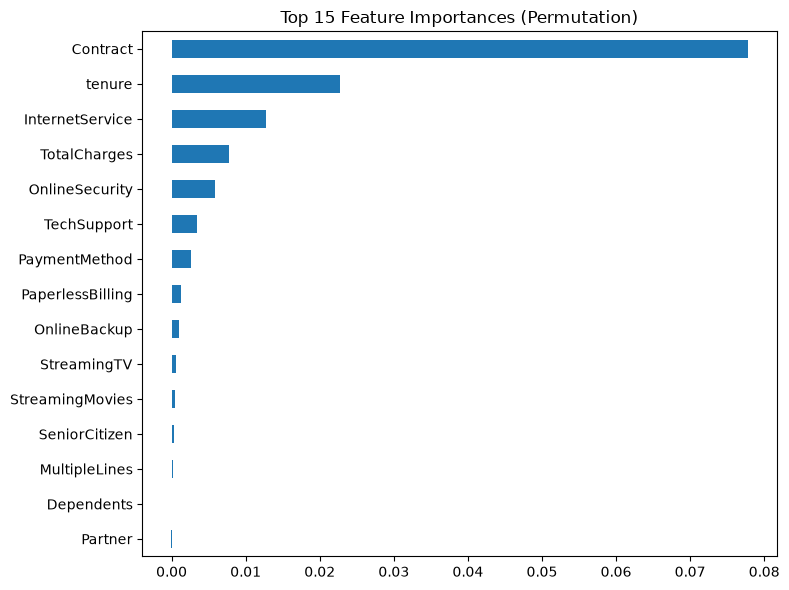

In [63]:
# permutation_importance shuffles original X columns (length = X_test.shape[1])
result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
)

importances = (
    pd.Series(result.importances_mean, index=X_test.columns)
    .sort_values(ascending=False)
)

print(importances.head(10))

importances.head(15).plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 Feature Importances (Permutation)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretability conclusions (typical run):**

1. **`Contract`** dominates — month-to-month vs longer commitments is the strongest churn signal; retention should prioritize locking in contract length.
2. **`tenure`** ranks high — confirms EDA: early-lifecycle customers need onboarding / win-back focus.
3. **`InternetService`** is a major product driver — plan mix (e.g. fiber vs DSL) matters.
4. Support add-ons (`OnlineSecurity`, `TechSupport`) contribute modestly — bundling may improve stickiness.
5. Demographics usually matter less once contract / tenure / service are known.

These insights connect the model back to business action, which is why interpretability is part of the pipeline — not an afterthought.


## 12. Save the model

We persist the **entire pipeline** (preprocessor + tuned classifier) with `joblib`.

**Why the full pipeline, not just the forest?**  
At inference time you must apply the *same* scaling / one-hot mapping learned during training. Saving only the classifier would require manually re-creating those transforms and risks train/serve skew.


In [64]:
import joblib

model_path = Path("models") if Path("models").is_dir() else Path("../models")
model_path.mkdir(parents=True, exist_ok=True)
out_file = model_path / "best_model.pkl"

joblib.dump(best_model, out_file)
print("Saved:", out_file.resolve())

Saved: /Users/shrutidoshi/Documents/repo/customer-churn-prediction-sklearn/models/best_model.pkl


## Summary — decisions at a glance

| Stage | Choice | Reason |
|---|---|---|
| Problem framing | Optimize ROC-AUC + churn recall | Imbalanced labels; missed churners are costly |
| Cleaning | Coerce/impute `TotalCharges`; drop ID | Make numerics usable; remove non-features |
| Split | Stratified 80/20 | Preserve churn rate; honest holdout |
| Preprocessing | `ColumnTransformer` inside `Pipeline` | No leakage; correct dtypes handling |
| Imbalance | `class_weight='balanced'` | Don't ignore minority class |
| Baseline | Logistic Regression | Strong, simple reference |
| Final model | Tuned shallow Random Forest | CV ROC-AUC improved after limiting depth |
| Explanation | Permutation importance on raw columns | Actionable drivers for the business |

Re-run this notebook top-to-bottom after placing the CSV in `data/`. Plots are written to `graphs/`; the model artifact is written to `models/best_model.pkl`.
